# MTH9899 DS Project — Intraday Data Analysis

This notebook explores and analyzes intraday market data from the `data_intraday/` folder.

**Data columns:**
- **Date** — Trading date (YYYYMMDD)
- **Time** — Intraday timestamp
- **Id** — Security identifier (Bloomberg-style)
- **CumReturnResid** — Cumulative return residual
- **CumReturnRaw** — Raw cumulative return
- **CumVolume** — Cumulative volume

## 1. Setup and imports

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Load data

In [137]:
data_dir = Path('data_intraday')
date_strings = sorted(p.stem for p in data_dir.glob('*.csv'))
print(f'Found {len(date_strings)} trading dates: {date_strings[0]} to {date_strings[-1]}')

Found 1258 trading dates: 20100104 to 20141231


## 3. Target variable construction

**Definition (per project spec):** At 15:30 each day, the target is the **return over the next 24 hours** for each security Id:
- **Part A:** Return from 15:30→16:00 "today" = `CumReturnResid` at 16:00 − `CumReturnResid` at 15:30 on the same day.
- **Part B:** Next day's cumulative residual return at 15:30 = `CumReturnResid` at 15:30 on the **next trading day** (return from today 16:00 to next day 15:30).

**Target = Part A + Part B.** We only keep (Date, Id) where both times exist on day D and 15:30 exists on day D+1 (next trading day). Optionally clip the target and normalize by EST_VOL (from daily data); when using EST_VOL, scale predictions back to return space for evaluation.

In [138]:
def build_target_single_day(data_dir, date_str, next_date_str):
    """
    Build target for one date D: return over next 24h from 15:30 on D.
    Target = (CumReturnResid at 16:00 - CumReturnResid at 15:30) on D  [today 15:30→16:00]
           + CumReturnResid at 15:30 on next_date  [16:00 D → 15:30 D+1]
    Returns DataFrame with columns Date, Id, Target (and part_a, part_b).
    """
    path_today = Path(data_dir) / f'{date_str}.csv'
    path_next = Path(data_dir) / f'{next_date_str}.csv'
    if not path_today.exists() or not path_next.exists():
        return None
    full = pd.read_csv(path_today)
    full_next = pd.read_csv(path_next)
    r1530_t = full[full['Time'].str.startswith('15:30')].set_index('Id')['CumReturnResid'].rename('r1530')
    r1600_t = full[full['Time'].str.startswith('16:00')].set_index('Id')['CumReturnResid'].rename('r1600')
    r1530_next = full_next[full_next['Time'].str.startswith('15:30')].set_index('Id')['CumReturnResid'].rename('r1530_next')
    part_a = (r1600_t - r1530_t).rename('part_a')
    part_b = r1530_next
    out = pd.DataFrame({'part_a': part_a, 'part_b': part_b}).dropna(how='any')
    out['Target'] = out['part_a'] + out['part_b']
    out['Date'] = int(date_str)
    return out.reset_index()[['Date', 'Id', 'Target', 'part_a', 'part_b']]


# Build target for all consecutive trading day pairs (date_strings from Section 2)
target_dfs = []
for i in range(len(date_strings) - 1):
    d_today, d_next = date_strings[i], date_strings[i + 1]
    one = build_target_single_day(data_dir, d_today, d_next)
    if one is not None:
        target_dfs.append(one)
target_df = pd.concat(target_dfs, ignore_index=True)
print(f'Target built for {target_df["Date"].nunique()} dates, {len(target_df):,} (Date, Id) rows')
target_df.head(10)

Target built for 1257 dates, 623,569 (Date, Id) rows


,Date,Id,Target,part_a,part_b
0,20100104,BBG000B9WH86,-0.037846,0.001505,-0.039352
1,20100104,BBG000B9WJ73,0.023476,0.002630,0.020846
2,20100104,BBG000B9XRY4,-0.001072,0.000818,-0.001890
3,20100104,BBG000B9XYV2,0.015305,0.001608,0.013697
4,20100104,BBG000B9YJ35,-0.021215,-0.001692,-0.019523
5,20100104,BBG000B9ZXB4,0.003299,-0.000396,0.003695
6,20100104,BBG000BB07P9,0.001098,0.000309,0.000789
7,20100104,BBG000BB1TH9,-0.000795,0.000586,-0.001381
8,20100104,BBG000BB29X4,-0.003348,-0.000461,-0.002887
9,20100104,BBG000BB2DM7,0.016519,0.000427,0.016093


In [139]:
# --- Clipping (recommended before fitting) ---
# Clip target cross-sectionally at 5 MAD (Median Absolute Deviation) per date, or use symmetric percentiles
def clip_target_cross_sectional(df, col='Target', n_mad=5):
    """Clip target at ±n_mad * MAD per date (cross-sectional)."""
    mad = df.groupby('Date')[col].transform(lambda x: np.median(np.abs(x - np.median(x))))
    median = df.groupby('Date')[col].transform('median')
    lower = median - n_mad * mad
    upper = median + n_mad * mad
    out = df.copy()
    out[f'{col}_clipped'] = out[col].clip(lower=lower, upper=upper)
    return out

target_df = clip_target_cross_sectional(target_df, col='Target', n_mad=5)
# Use Target_clipped for fitting; keep Target for evaluation if needed
print('Target stats (raw vs clipped):')
print(target_df[['Target', 'Target_clipped']].describe())

Target stats (raw vs clipped):
              Target  Target_clipped
count  623569.000000   623569.000000
mean        0.000025       -0.000038
std         0.014182        0.010702
min        -0.788171       -0.058163
25%        -0.005822       -0.005822
50%        -0.000205       -0.000205
75%         0.005571        0.005571
max         1.948899        0.058939


In [140]:
# (redundant cell removed)

### 3.1 Train / validation split

**Split (per project spec):**
- **Validation:** 2014 (one year).
- **Training:** All prior periods — 2010 to 2013 (four years).
- **Hold-out test:** One additional year will be provided later; do not use it for development and do not refit after you receive it.

We build features for 2010–2014; validation (2014) is used for model selection and reporting OOS R².

In [141]:
# Extract calendar year from Date (YYYYMMDD)
df = target_df.copy()
df['Year'] = (df['Date'] // 10_000).astype(int)

# Validation = 2014, Training = all prior periods (2010-2013). Hold-out test year TBA.
val_year = 2014
train_years = [2010, 2011, 2012, 2013]
dev_years = train_years + [val_year]   # 2010-2014: all years we use for features and split

df = df[df['Year'].isin(dev_years)].copy()
train_df = df[df['Year'].isin(train_years)].drop(columns=['Year']).copy()
val_df = df[df['Year'] == val_year].drop(columns=['Year']).copy()

print('Development years (features + split):', dev_years)
print(f'Train: years {train_years}  →  {train_df["Date"].nunique()} dates, {len(train_df):,} rows')
print(f'Validation: year {val_year}  →  {val_df["Date"].nunique()} dates, {len(val_df):,} rows')
if len(train_df) == 0:
    print('  → Train is empty: ensure intraday and daily data include 2010–2013.')
if len(val_df) == 0:
    print('  → Validation is empty: ensure data includes 2014.')
train_df.head()

Development years (features + split): [2010, 2011, 2012, 2013, 2014]
Train: years [2010, 2011, 2012, 2013]  →  1006 dates, 498,724 rows
Validation: year 2014  →  251 dates, 124,845 rows


,Date,Id,Target,part_a,part_b,Target_clipped
0,20100104,BBG000B9WH86,-0.037846,0.001505,-0.039352,-0.037846
1,20100104,BBG000B9WJ73,0.023476,0.002630,0.020846,0.023476
2,20100104,BBG000B9XRY4,-0.001072,0.000818,-0.001890,-0.001072
3,20100104,BBG000B9XYV2,0.015305,0.001608,0.013697,0.015305
4,20100104,BBG000B9YJ35,-0.021215,-0.001692,-0.019523,-0.021215


## 4. Daily data preparation

Load daily data from `hw2/dat.YYYYMMDD.csv`. At 15:30 we do **not** have same-day daily data → use the **previous trading day's** daily data for EST_VOL, MDV_63, and daily-only features (no look-ahead). **Adjustments:** Close_adj = Close × PxAdjFactor (for returns). DollarVol = Volume × SharesAdjFactor × Close_adj (volume comparable across splits/dividends).

In [142]:
hw2_dir = Path('hw2')
daily_files = sorted(hw2_dir.glob('dat.*.csv'))
daily_dfs = []
for f in daily_files:
    date_int = int(f.stem.split('.')[1])  # dat.20100104 -> 20100104
    df = pd.read_csv(f)
    df['Date'] = date_int
    df = df.rename(columns={'ID': 'Id'})
    # Price: comparable across days via PxAdjFactor. Close_adj = Close * PxAdjFactor.
    df['Close_adj'] = df['Close'] * df['PxAdjFactor']
    # Dollar volume: comparable across days via both factors. Volume_adj in share units, then * Close_adj.
    df['DollarVol'] = (df['Volume'] * df['SharesAdjFactor']) * df['Close_adj']
    daily_dfs.append(df[['Date', 'Id', 'EST_VOL', 'MDV_63', 'Close', 'Volume', 'PxAdjFactor', 'SharesAdjFactor', 'Close_adj', 'DollarVol']])
daily_all = pd.concat(daily_dfs, ignore_index=True)

# Previous trading day for each date (no same-day daily data at 15:30 → use prev day)
date_list = [int(d) for d in date_strings]
prev_date = {date_list[i]: date_list[i - 1] for i in range(1, len(date_list))}

print(f'Daily data: {len(daily_all):,} rows, {daily_all["Date"].nunique()} dates')
print(f'Prev-date mapping: e.g. {date_list[1]} -> {prev_date[date_list[1]]}')
daily_all.head()

Daily data: 629,000 rows, 1258 dates
Prev-date mapping: e.g. 20100105 -> 20100104


,Date,Id,EST_VOL,MDV_63,Close,Volume,PxAdjFactor,SharesAdjFactor,Close_adj,DollarVol
0,20100104,BBG000MQ1SN9,0.13074,43832748.0,59.92,955120.0,1.000000,1.0,59.920000,5.723079e+07
1,20100104,BBG000BBCQD7,0.31610,44092964.0,11.54,2566745.0,1.000000,1.0,11.540000,2.962024e+07
2,20100104,BBG000BBB3K1,0.11253,75886260.0,53.24,812905.0,1.160364,1.0,61.777763,5.021945e+07
3,20100104,BBG000BNMHS4,0.18568,44133930.0,56.41,1108030.0,1.034430,1.0,58.352185,6.465597e+07
4,20100104,BBG000C23PB0,0.11252,44405412.0,19.11,3500468.0,1.000000,1.0,19.110000,6.689394e+07


## 5. Intraday and daily features

All features are computed as of 15:30. Daily data uses the **previous trading day** only (no look-ahead). After computing raw values, we winsorize then z-score cross-sectionally within each date (unless noted).

---

### Intraday features (from intraday data only)

| Feature | Definition | Formula | Normalization | Motivation |
|--------|------------|---------|----------------|------------|
| **Overnight Return** | Cumulative residual return from prior close to 09:45 open. | `CumReturnResid` at 09:45 | ±5 MAD, then z-score cross-sectional | Captures gap/overnight sentiment. |
| **Last-Hour Intraday Momentum** | Return from 14:30 to 15:30. | `CumReturnResid_15:30 − CumReturnResid_14:30` | ±5 MAD, then z-score | Recent intraday momentum. |
| **Intraday Reversal** | Morning move vs afternoon move (reversal). | Morning = (12:00 − 09:45), Afternoon = (15:30 − 12:00); feat = Morning − Afternoon | ±5 MAD, then z-score | Stocks that ran up in the morning often give back in the afternoon. |
| **Intraday Volatility** | Dispersion of 15-min return increments from 09:45 to 15:30. | Std of `CumReturnResid` differences across consecutive times | [1st, 99th] percentile, then z-score | Higher intraday vol can predict next-day behavior. |
| **Volume Surprise** | Cumulative volume by 15:30 vs 3-month baseline. | `CumVolume_15:30 / MDV_63_prev` (prev day's MDV; NaN if prev day MDV missing) | [1st, 99th] percentile, then z-score | Unusual volume may signal information. |
| **Return–Volume Correlation** | Correlation of 15-min return increments with volume increments (09:45–15:30). | Corr(ΔCumReturnResid, ΔCumVolume) per security | Z-score only (no winsorize) | Tells if price moves are accompanied by volume. |

---

### Daily features (use daily data; at 15:30 we use previous trading day only)

| Feature | Definition | Formula | Normalization | Motivation |
|--------|------------|---------|----------------|------------|
| **Volatility-Adjusted Return** | Intraday residual return at 15:30 in risk units. | `CumReturnResid_15:30 / EST_VOL_prev` (prev day's EST_VOL) | ±5 MAD, then z-score | Makes returns comparable on a risk-adjusted basis. |
| **Short-Term Reversal (1-day)** | Prior day's adjusted close-to-close return. | `ret_1d = (Close_adj)_{t−1} / (Close_adj)_{t−2} − 1` with Close_adj = Close × PxAdjFactor | ±5 MAD, then z-score | Yesterday's losers tend to outperform (reversal). |
| **Medium-Term Momentum (21-day)** | Cumulative adjusted return over past 21 trading days, skipping t−1. | `ret_21d = (Close_adj)_{t−2} / (Close_adj)_{t−23} − 1` | ±5 MAD, then z-score | Recent winners tend to continue (momentum). |
| **Dollar Volume Trend** | Recent trading interest vs 3-month baseline. | `avg_dv_5d = mean(Volume × SharesAdjFactor × Close_adj, t−1..t−5)`; `feat = avg_dv_5d / MDV_63` (prev day) | ±5 MAD, then z-score | Expanding volume vs baseline may signal catalyst or interest. |

*Note: Dollar volume uses Volume × SharesAdjFactor × Close_adj so it is comparable across splits/dividends.*

**Why some features have NaNs (before we fill them):**

| Cause | Affected features |
|-------|-------------------|
| **First trading date** | No previous day → no EST_VOL/MDV_63 merge → VolatilityAdjustedReturn and VolumeSurprise (NaN when prev day MDV missing). |
| **First ~23 trading days** | ShortTermReversal, Momentum21d, DollarVolTrend need 2+ and 23+ days of daily history, so not computed for early dates. |
| **Id in intraday but not in daily** | Universe adds/drops names; left merge leaves daily-based features NaN for that (Date, Id). |
| **Constant series** | If return or volume is constant over the day, std=0 or correlation undefined → IntradayVolatility or RetVolCorr (and their z-scores) NaN. |

We **drop rows with any NaN** in the feature columns so train/val have no missing values for modeling.

In [143]:
# Times we need (snapshots from 09:45 to 15:30 for volatility/correlation; specific times for others)
TIME_0945, TIME_1200, TIME_1430, TIME_1530 = '09:45', '12:00', '14:30', '15:30'

def load_day_pivoted(data_dir, date_str):
    """Load one day's intraday CSV; return wide DataFrames: CumReturnResid and CumVolume at each time (index=Id)."""
    path = Path(data_dir) / f'{date_str}.csv'
    if not path.exists():
        return None, None
    df = pd.read_csv(path)
    df['TimeStr'] = df['Time'].str[:5]  # e.g. 09:45:00.000 -> 09:45
    r = df.pivot_table(index='Id', columns='TimeStr', values='CumReturnResid', aggfunc='first')
    v = df.pivot_table(index='Id', columns='TimeStr', values='CumVolume', aggfunc='first')
    return r, v

def features_single_day(r, v, date_int):
    """Compute 6 intraday features for one day. r, v = CumReturnResid and CumVolume pivoted by time."""
    out = pd.DataFrame(index=r.index)
    out['Date'] = date_int
    out['Id'] = out.index
    # 1. Overnight return
    if TIME_0945 in r.columns:
        out['OvernightReturn'] = r[TIME_0945].values
    # 2. Last-hour momentum (14:30 -> 15:30); when difference is 0 keep 0, otherwise use .values
    if TIME_1430 in r.columns and TIME_1530 in r.columns:
        out['LastHourMomentum'] = (r[TIME_1530] - r[TIME_1430]).values
    # CumReturnResid at 15:30 (for Volatility-Adjusted Return; daily EST_VOL from prev day)
    if TIME_1530 in r.columns:
        out['CumReturnResid_1530'] = r[TIME_1530].values
    # 3. Intraday reversal (morning - afternoon)
    if all(t in r.columns for t in [TIME_0945, TIME_1200, TIME_1530]):
        morning = r[TIME_1200] - r[TIME_0945]
        afternoon = r[TIME_1530] - r[TIME_1200]
        out['IntradayReversal'] = (morning - afternoon).values
    # 4. Intraday volatility (std of 15-min return increments 09:45 to 15:30)
    times_ordered = [c for c in r.columns if c >= TIME_0945 and c <= TIME_1530]
    times_ordered = sorted(times_ordered, key=lambda t: (int(t[:2]), int(t[3:5])))
    if len(times_ordered) >= 2:
        ret_inc = r[times_ordered].diff(axis=1).iloc[:, 1:]
        out['IntradayVolatility'] = ret_inc.std(axis=1).values
    # 5. Volume surprise (CumVolume_1530 / MDV_63) — requires daily data; fill 1 if missing
    # Align v to r.index (r may have fewer Ids due to missing CumReturnResid)
    if v is not None and TIME_1530 in v.columns:
        out['CumVolume_1530'] = v.reindex(r.index)[TIME_1530].values
    # 6. Return–volume correlation (corr of ret_inc vs vol_inc)
    if len(times_ordered) >= 2 and v is not None:
        ret_inc = r[times_ordered].diff(axis=1).iloc[:, 1:]
        v_aligned = v.reindex(r.index)[times_ordered]
        vol_inc = v_aligned.diff(axis=1).iloc[:, 1:]
        out['RetVolCorr'] = ret_inc.corrwith(vol_inc, axis=1).values
    return out.reset_index(drop=True)

def winsorize_mad(df, col, n_mad=5):
    """Winsorize at ±n_mad * MAD cross-sectionally per date."""
    mad = df.groupby('Date')[col].transform(lambda x: np.median(np.abs(x - np.median(x))))
    mad = mad.replace(0, np.nan)
    med = df.groupby('Date')[col].transform('median')
    lo = med - n_mad * mad
    hi = med + n_mad * mad
    return df[col].clip(lower=lo.fillna(-np.inf), upper=hi.fillna(np.inf))

def winsorize_percentile(df, col, low=0.01, high=0.99):
    """Winsorize at [low, high] percentiles cross-sectionally per date."""
    lo = df.groupby('Date')[col].transform(lambda x: x.quantile(low))
    hi = df.groupby('Date')[col].transform(lambda x: x.quantile(high))
    return df[col].clip(lower=lo, upper=hi)

def zscore_cross_sectional(df, col):
    """Z-score within each date (cross-sectional). Use np.nan when std is 0."""
    return df.groupby('Date')[col].transform(lambda x: (x - x.mean()) / (x.std() or np.nan))

# Build features for all dates in dev_years (2010-2014)
dev_dates = [int(d) for d in date_strings if int(d) // 10_000 in dev_years]
feature_dfs = []
for date_str in date_strings:
    date_int = int(date_str)
    if date_int not in dev_dates:
        continue
    r, v = load_day_pivoted(data_dir, date_str)
    if r is None:
        continue
    one = features_single_day(r, v, date_int)
    feature_dfs.append(one)
feat_df = pd.concat(feature_dfs, ignore_index=True)

# Merge previous trading day's daily data (no look-ahead: at 15:30 we don't have same-day daily)
daily_prev_list = []
for D in feat_df['Date'].unique():
    D_prev = prev_date.get(D)
    if D_prev is None:
        continue
    d = daily_all[daily_all['Date'] == D_prev][['Id', 'EST_VOL', 'MDV_63']].copy()
    d = d.rename(columns={'EST_VOL': 'EST_VOL_prev', 'MDV_63': 'MDV_63_prev'})
    d['Date'] = D
    daily_prev_list.append(d)
daily_prev_merge = pd.concat(daily_prev_list, ignore_index=True)
feat_df = feat_df.merge(daily_prev_merge, on=['Date', 'Id'], how='left')

# Volume Surprise = CumVolume_1530 / MDV_63_prev (prev day); NaN if prev day MDV missing or zero
feat_df['VolumeSurprise'] = feat_df['CumVolume_1530'] / feat_df['MDV_63_prev'].replace(0, np.nan)
# Volatility-Adjusted Return = CumReturnResid_1530 / EST_VOL_prev (prev day)
feat_df['VolatilityAdjustedReturn'] = feat_df['CumReturnResid_1530'] / feat_df['EST_VOL_prev'].replace(0, np.nan)

# Daily-only features (all use past days only; no look-ahead)
# Short-term reversal: (Close*PxAdj)_{t-1} / (Close*PxAdj)_{t-2} - 1
# Momentum 21d: Close_adj_{t-2} / Close_adj_{t-23} - 1  (skip t-1 to avoid reversal)
# Dollar volume trend: mean(DollarVol, t-1..t-5) / MDV_63_{t-1}
daily_feat_list = []
for D in feat_df['Date'].unique():
    if D not in prev_date:
        continue
    D_prev = prev_date[D]
    D_prev2 = prev_date.get(D_prev)
    if D_prev2 is None:
        continue
    idx = date_list.index(D)
    if idx < 23:
        continue
    D_prev23 = date_list[idx - 23]  # 21 trading days before D_prev2 (D_prev2 is at idx-2)
    d1 = daily_all[daily_all['Date'] == D_prev][['Id', 'Close_adj', 'DollarVol', 'MDV_63']].rename(columns={'Close_adj': 'c1', 'DollarVol': 'dv1', 'MDV_63': 'MDV_63_1'})
    d2 = daily_all[daily_all['Date'] == D_prev2][['Id', 'Close_adj']].rename(columns={'Close_adj': 'c2'})
    d23 = daily_all[daily_all['Date'] == D_prev23][['Id', 'Close_adj']].rename(columns={'Close_adj': 'c23'})
    m = d1.merge(d2, on='Id', how='inner').merge(d23, on='Id', how='inner')
    m['ShortTermReversal'] = (m['c1'] / m['c2']) - 1
    m['Momentum21d'] = (m['c2'] / m['c23']) - 1
    # avg_dv_5d = mean(DollarVol) for t-1..t-5
    d_ = D_prev
    dv_list = []
    for _ in range(5):
        if d_ is None:
            break
        dv_list.append(daily_all[daily_all['Date'] == d_][['Id', 'DollarVol']])
        d_ = prev_date.get(d_)
    if len(dv_list) == 5:
        dv_5d = dv_list[0].rename(columns={'DollarVol': 'v0'})
        for i, df in enumerate(dv_list[1:], 1):
            dv_5d = dv_5d.merge(df.rename(columns={'DollarVol': f'v{i}'}), on='Id', how='outer')
        dv_5d['avg_dv_5d'] = dv_5d[['v0', 'v1', 'v2', 'v3', 'v4']].mean(axis=1)
        m = m.merge(dv_5d[['Id', 'avg_dv_5d']], on='Id', how='left')
        m['DollarVolTrend'] = m['avg_dv_5d'] / m['MDV_63_1'].replace(0, np.nan)
    else:
        m['DollarVolTrend'] = np.nan
    m = m[['Id', 'ShortTermReversal', 'Momentum21d', 'DollarVolTrend']].copy()
    m['Date'] = D
    daily_feat_list.append(m)
if daily_feat_list:
    daily_feat_df = pd.concat(daily_feat_list, ignore_index=True)
    feat_df = feat_df.merge(daily_feat_df, on=['Date', 'Id'], how='left')

# Normalize: ±5 MAD + z-score for Overnight, LastHour, Reversal, VolatilityAdjustedReturn, ShortTermReversal, Momentum21d, DollarVolTrend; [1,99]% + z-score for Volatility, VolumeSurprise; z-score only for RetVolCorr
for col, use_mad in [('OvernightReturn', True), ('LastHourMomentum', True), ('IntradayReversal', True),
                     ('IntradayVolatility', False), ('VolumeSurprise', False),
                     ('VolatilityAdjustedReturn', True), ('ShortTermReversal', True), ('Momentum21d', True), ('DollarVolTrend', True)]:
    if col not in feat_df.columns:
        continue
    if use_mad:
        feat_df[f'{col}_w'] = winsorize_mad(feat_df, col, n_mad=5)
    else:
        feat_df[f'{col}_w'] = winsorize_percentile(feat_df, col, 0.01, 0.99)
    feat_df[f'{col}_norm'] = zscore_cross_sectional(feat_df, f'{col}_w')
if 'RetVolCorr' in feat_df.columns:
    feat_df['RetVolCorr_norm'] = zscore_cross_sectional(feat_df, 'RetVolCorr')

# Keep only normalized feature columns and keys
norm_cols = [c for c in feat_df.columns if c.endswith('_norm')]
feat_df = feat_df[['Date', 'Id'] + norm_cols].copy()
feat_df.columns = ['Date', 'Id'] + [c.replace('_norm', '') for c in norm_cols]
feature_cols = [c for c in feat_df.columns if c not in ('Date', 'Id')]
print('Features built:', feature_cols)
print('Shape:', feat_df.shape)

feat_df = feat_df.dropna(subset=feature_cols)
print(f'\nAfter dropping rows with NaN: {len(feat_df):,} rows')

# Merge features to train/validation (inner join: only (Date,Id) present in both target and features)
# Keep only keys + non-feature columns from left to avoid duplicate columns when re-running this cell
left_cols = ['Date', 'Id'] + [c for c in train_df.columns if c not in feat_df.columns]
train_df = train_df[left_cols].merge(feat_df, on=['Date', 'Id'], how='inner')
val_df = val_df[left_cols].merge(feat_df, on=['Date', 'Id'], how='inner')
print(f'Train with features: {len(train_df):,} rows, {len(feature_cols)} features')
print(f'Validation with features: {len(val_df):,} rows')
feat_df.head(10)

Features built: ['OvernightReturn', 'LastHourMomentum', 'IntradayReversal', 'IntradayVolatility', 'VolumeSurprise', 'VolatilityAdjustedReturn', 'ShortTermReversal', 'Momentum21d', 'DollarVolTrend', 'RetVolCorr']
Shape: (626431, 12)

After dropping rows with NaN: 587,425 rows
Train with features: 466,880 rows, 10 features
Validation with features: 118,897 rows


,Date,Id,OvernightReturn,LastHourMomentum,IntradayReversal,IntradayVolatility,VolumeSurprise,VolatilityAdjustedReturn,ShortTermReversal,Momentum21d,DollarVolTrend,RetVolCorr
11333,20100205,BBG000B9WH86,0.119360,-0.572998,0.762285,-0.707518,0.864796,0.237994,-0.328297,-2.026562,-0.056263,-1.413516
11334,20100205,BBG000B9WJ73,1.473551,-0.669631,-0.504615,2.463049,0.245748,0.364152,-0.839067,-0.440486,1.591212,0.606032
11335,20100205,BBG000B9XRY4,0.655399,0.335509,0.350026,-0.643849,-1.042775,0.788455,0.024653,-0.542302,0.277440,0.270883
11336,20100205,BBG000B9XYV2,-0.568270,-1.605976,0.725341,-0.017611,0.150279,-1.245549,-0.245591,0.127115,-0.414102,-0.682245
11337,20100205,BBG000B9YJ35,-0.872722,-0.822081,0.522848,-0.853889,-0.491708,0.187374,-0.543807,-1.177167,-0.680192,1.987677
11339,20100205,BBG000B9ZXB4,0.352137,0.378365,0.057197,-1.050843,-0.534264,0.902872,1.082642,0.454474,0.381838,-0.239007
11340,20100205,BBG000BB07P9,0.067544,-1.229496,1.783415,-0.068823,-0.413041,0.451850,-0.845526,-1.064605,-1.005476,-0.403308
11341,20100205,BBG000BB1TH9,-0.996322,-0.818599,-0.191671,0.506435,-0.501608,-1.477572,-0.846368,0.533747,-0.830815,-1.396079
11342,20100205,BBG000BB29X4,0.005471,-0.641512,0.089492,-1.320514,-0.561836,0.482938,0.747631,0.073015,-0.857536,0.093000
11343,20100205,BBG000BB2DM7,0.295379,-0.062570,-0.495242,-0.266545,0.686969,0.090281,-1.036993,-0.671915,-0.512275,0.532877


## 5.1 Align with spec (target, normalization, weights)

- **Target:** Use clipped target for fitting (already in `Target_clipped`).
- **Normalization:** Fit on `target / EST_VOL`; at prediction time scale back: `pred_return = pred_norm * EST_VOL`.
- **Weights:** Use `sqrt(MDV_63)` as sample weights when fitting. *Why MDV_63:* more liquid names (higher median daily volume) have more stable return estimates; √MDV_63 upweights them while muting a few very high-MDV names dominating the fit (spec: use sqrt or log).
- **Validation:** 2014 = validation set; 2010–2013 = training set; hold-out test TBA.

In [144]:
# Build (Date, Id, EST_VOL_prev, MDV_63_prev) for all dates that have a previous trading day
daily_prev_list = []
for D in pd.concat([train_df[['Date']], val_df[['Date']]], ignore_index=True)['Date'].unique():
    D_prev = prev_date.get(D)
    if D_prev is None:
        continue
    d = daily_all[daily_all['Date'] == D_prev][['Id', 'EST_VOL', 'MDV_63']].copy()
    d = d.rename(columns={'EST_VOL': 'EST_VOL_prev', 'MDV_63': 'MDV_63_prev'})
    d['Date'] = D
    daily_prev_list.append(d)
daily_prev = pd.concat(daily_prev_list, ignore_index=True)

# Merge EST_VOL_prev and MDV_63_prev into train and val (for normalization and sample weights)
train_df = train_df.merge(daily_prev[['Date', 'Id', 'EST_VOL_prev', 'MDV_63_prev']], on=['Date', 'Id'], how='left')
val_df = val_df.merge(daily_prev[['Date', 'Id', 'EST_VOL_prev', 'MDV_63_prev']], on=['Date', 'Id'], how='left')

# Drop rows where EST_VOL_prev is missing or 0 so Target_norm is well-defined
train_df = train_df[train_df['EST_VOL_prev'].notna() & (train_df['EST_VOL_prev'] > 0)].copy()
val_df = val_df[val_df['EST_VOL_prev'].notna() & (val_df['EST_VOL_prev'] > 0)].copy()

# Normalized target for fitting (spec: fit on target / EST_VOL; scale back at prediction time)
train_df['Target_norm'] = train_df['Target_clipped'] / train_df['EST_VOL_prev']
val_df['Target_norm'] = val_df['Target_clipped'] / val_df['EST_VOL_prev']

# Sample weights: sqrt(MDV_63) to mute effect of a few IDs dominating the fit
train_df['sample_weight'] = np.sqrt(train_df['MDV_63_prev'].replace(0, np.nan))
val_df['sample_weight'] = np.sqrt(val_df['MDV_63_prev'].replace(0, np.nan))
train_df = train_df.dropna(subset=['sample_weight'])
val_df = val_df.dropna(subset=['sample_weight'])

print('Align with spec:')
print(f'  Target for fitting: Target_clipped (already clipped at ±5 MAD).')
print(f'  Normalized target: Target_norm = Target_clipped / EST_VOL_prev (use for fitting; scale back by EST_VOL when predicting).')
print(f'  Sample weights: sqrt(MDV_63_prev) applied per row.')
print(f'  Train: {len(train_df):,} rows (years {train_years}); Val: {len(val_df):,} rows (year {val_year}).')
print(f'  Hold-out test year will be provided later; do not refit after it is received.')
train_df[['Date', 'Id', 'Target_clipped', 'EST_VOL_prev', 'Target_norm', 'sample_weight']].head()

Align with spec:
  Target for fitting: Target_clipped (already clipped at ±5 MAD).
  Normalized target: Target_norm = Target_clipped / EST_VOL_prev (use for fitting; scale back by EST_VOL when predicting).
  Sample weights: sqrt(MDV_63_prev) applied per row.
  Train: 466,880 rows (years [2010, 2011, 2012, 2013]); Val: 118,897 rows (year 2014).
  Hold-out test year will be provided later; do not refit after it is received.


,Date,Id,Target_clipped,EST_VOL_prev,Target_norm,sample_weight
0,20100205,BBG000B9WH86,0.005950,0.25809,0.023053,20787.854627
1,20100205,BBG000B9WJ73,-0.033242,0.31770,-0.104633,9733.527624
2,20100205,BBG000B9XRY4,-0.003181,0.18137,-0.017538,59609.358326
3,20100205,BBG000B9XYV2,-0.002180,0.18123,-0.012030,10586.423381
4,20100205,BBG000B9YJ35,0.007704,0.17780,0.043328,6560.578481


## 6. Feature testing, cleaning, and normalization

**Summary for white paper:**
- **Testing:** Features are evaluated via train/validation split (2010–2013 train, 2014 val); model weighted R² on validation is the main metric. No formal univariate screening; all engineered features are kept and used in the models.
- **Cleaning:** Rows with any missing value in the feature set are dropped (`dropna(subset=feature_cols)`). Rows without valid `EST_VOL_prev` or `MDV_63_prev` (for target normalization and sample weights) are dropped. Target is clipped at ±5 MAD cross-sectionally before fitting.
- **Normalization:** (1) **Features:** Raw features are winsorized (±5 MAD for most, 1st–99th percentile for volatility/volume) then z-scored cross-sectionally within each date. (2) **Target:** We fit on normalized target `Target_norm = Target_clipped / EST_VOL_prev`; predictions are scaled back to return space by multiplying by `EST_VOL` at prediction time.

In [145]:
# Quick reference: feature list and normalization (matches Section 5 feature build)
mad_features = ['OvernightReturn', 'LastHourMomentum', 'IntradayReversal', 'VolatilityAdjustedReturn', 'ShortTermReversal', 'Momentum21d', 'DollarVolTrend']
pct_features = ['IntradayVolatility', 'VolumeSurprise']
feat_normalization = pd.DataFrame({
    'Feature': feature_cols,
    'Winsorization': ['±5 MAD' if f in mad_features else ('1st–99th pct' if f in pct_features else 'None') for f in feature_cols],
    'Cross-sectional': 'Z-score',
})
print('Feature cleaning/normalization applied:')
display(feat_normalization)

Feature cleaning/normalization applied:


,Feature,Winsorization,Cross-sectional
0,OvernightReturn,±5 MAD,Z-score
1,LastHourMomentum,±5 MAD,Z-score
2,IntradayReversal,±5 MAD,Z-score
3,IntradayVolatility,1st–99th pct,Z-score
4,VolumeSurprise,1st–99th pct,Z-score
5,VolatilityAdjustedReturn,±5 MAD,Z-score
6,ShortTermReversal,±5 MAD,Z-score
7,Momentum21d,±5 MAD,Z-score
8,DollarVolTrend,±5 MAD,Z-score
9,RetVolCorr,None,Z-score


In [159]:
# Feature categories and full list (for white paper)
intraday_features = ['OvernightReturn', 'LastHourMomentum', 'IntradayReversal', 'IntradayVolatility', 'VolumeSurprise', 'RetVolCorr']
daily_features = ['VolatilityAdjustedReturn', 'ShortTermReversal', 'Momentum21d', 'DollarVolTrend']
feature_categories = pd.DataFrame({
    'Feature': feature_cols,
    'Category': ['Intraday' if f in intraday_features else 'Daily' for f in feature_cols],
})
print('Feature categories and full list (for white paper):')
display(feature_categories)

Feature categories and full list (for white paper):


,Feature,Category
0,OvernightReturn,Intraday
1,LastHourMomentum,Intraday
2,IntradayReversal,Intraday
3,IntradayVolatility,Intraday
4,VolumeSurprise,Intraday
5,VolatilityAdjustedReturn,Daily
6,ShortTermReversal,Daily
7,Momentum21d,Daily
8,DollarVolTrend,Daily
9,RetVolCorr,Intraday


## 7. Models: Ridge, Random Forest, XGBoost (+ optional)

Required: **Ridge**, **Random Forest Regressor**, **XGBoost**. Fit on `Target_norm` with `sample_weight = sqrt(MDV_63)`. Tune hyperparameters on train/validation; report weighted R² on validation (weights = sqrt(MDV_63)).

In [146]:
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit
import warnings

# XGBoost (install if needed: pip install xgboost)
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    warnings.warn('XGBoost not installed; skip XGB model. pip install xgboost')

def weighted_r2(y_true, y_pred, sample_weight):
    """Weighted R² as per spec: use sqrt(MDV_63) for evaluation."""
    return r2_score(y_true, y_pred, sample_weight=sample_weight)

def clip_actuals_oos_5mad(df, target_col='Target_norm', date_col='Date', n_mad=5):
    """Clip actual returns at ±n_mad*MAD cross-sectionally per date (for OOS R² per spec)."""
    med = df.groupby(date_col)[target_col].transform('median')
    mad = df.groupby(date_col)[target_col].transform(lambda x: np.median(np.abs(x - np.median(x))))
    mad = mad.replace(0, np.nan)
    lo = med - n_mad * mad
    hi = med + n_mad * mad
    return df[target_col].clip(lower=lo.fillna(-np.inf), upper=hi.fillna(np.inf)).values

# Require non-empty train and validation before building matrices
if len(train_df) == 0 or len(val_df) == 0:
    raise ValueError(
        'Train or validation is empty. '
        'Train needs data for 2010–2013, validation for 2014. '
        'Ensure intraday and daily data (and target) include those years, then re-run from the split cell.'
    )

# Feature matrix and target (normalized for fitting)
X_train = train_df[feature_cols].astype(float)
y_train = train_df['Target_norm'].values
w_train = train_df['sample_weight'].values

X_val = val_df[feature_cols].astype(float)
y_val = val_df['Target_norm'].values
w_val = val_df['sample_weight'].values

print(f'Train: X {X_train.shape}, y {y_train.shape}, weights {w_train.shape}')
print(f'Val:   X {X_val.shape}, y {y_val.shape}, weights {w_val.shape}')
print(f'Features: {feature_cols}')

Train: X (466880, 10), y (466880,), weights (466880,)
Val:   X (118897, 10), y (118897,), weights (118897,)
Features: ['OvernightReturn', 'LastHourMomentum', 'IntradayReversal', 'IntradayVolatility', 'VolumeSurprise', 'VolatilityAdjustedReturn', 'ShortTermReversal', 'Momentum21d', 'DollarVolTrend', 'RetVolCorr']


In [147]:
# --- 1. Ridge Regression (required) ---
alphas = np.logspace(-3, 3, 25)  # 0.001 to 1000
ridge_scores = []
for alpha in alphas:
    m = Ridge(alpha=alpha, random_state=42)
    m.fit(X_train, y_train, sample_weight=w_train)
    pred_val = m.predict(X_val)
    r2 = weighted_r2(y_val, pred_val, w_val)
    ridge_scores.append((alpha, r2))
ridge_results = pd.DataFrame(ridge_scores, columns=['alpha', 'val_weighted_r2'])
best_alpha = ridge_results.loc[ridge_results['val_weighted_r2'].idxmax(), 'alpha']
ridge_best = Ridge(alpha=best_alpha, random_state=42)
ridge_best.fit(X_train, y_train, sample_weight=w_train)
ridge_val_r2 = weighted_r2(y_val, ridge_best.predict(X_val), w_val)
print('Ridge: best alpha =', best_alpha)
print('Ridge validation weighted R² =', round(ridge_val_r2, 6))
ridge_results.head(10)

Ridge: best alpha = 1000.0
Ridge validation weighted R² = 4e-05


,alpha,val_weighted_r2
0,0.001000,0.00004
1,0.001778,0.00004
2,0.003162,0.00004
3,0.005623,0.00004
4,0.010000,0.00004
5,0.017783,0.00004
6,0.031623,0.00004
7,0.056234,0.00004
8,0.100000,0.00004
9,0.177828,0.00004


In [148]:
# --- 2. Random Forest Regressor (required) ---
# Smaller grid + fewer trees during search for speed; refit best with more trees once
max_depths = [5, 8]
n_est_tune = 60   # fewer trees for fast grid search
min_leaf = [10, 20]
rf_scores = []
for md in max_depths:
    for ml in min_leaf:
        m = RandomForestRegressor(n_estimators=n_est_tune, max_depth=md, min_samples_leaf=ml, random_state=42, n_jobs=-1)
        m.fit(X_train, y_train, sample_weight=w_train)
        r2 = weighted_r2(y_val, m.predict(X_val), w_val)
        rf_scores.append({'max_depth': md, 'min_samples_leaf': ml, 'val_weighted_r2': r2})
rf_results = pd.DataFrame(rf_scores)
best_rf = rf_results.loc[rf_results['val_weighted_r2'].idxmax()]
# Final model with more trees for better accuracy (single fit)
n_est_final = 150
rf_best = RandomForestRegressor(
    n_estimators=n_est_final, max_depth=int(best_rf['max_depth']),
    min_samples_leaf=int(best_rf['min_samples_leaf']), random_state=42, n_jobs=-1
)
rf_best.fit(X_train, y_train, sample_weight=w_train)
rf_val_r2 = weighted_r2(y_val, rf_best.predict(X_val), w_val)
print('Random Forest: best params =', best_rf[['max_depth', 'min_samples_leaf']].to_dict(), f'(n_estimators={n_est_final} for final fit)')
print('Random Forest validation weighted R² =', round(rf_val_r2, 6))
rf_results.sort_values('val_weighted_r2', ascending=False)

Random Forest: best params = {'max_depth': 5.0, 'min_samples_leaf': 10.0} (n_estimators=150 for final fit)
Random Forest validation weighted R² = -2.6e-05


,max_depth,min_samples_leaf,val_weighted_r2
0,5,10,-0.000061
1,5,20,-0.000071
2,8,10,-0.000149
3,8,20,-0.000222


In [149]:
# --- 3. XGBoost Regressor (required) ---
if HAS_XGB:
    xgb_params = []
    for md in [3, 4, 5, 6]:
        for lr in [0.03, 0.05, 0.1]:
            for ne in [100, 200]:
                m = xgb.XGBRegressor(n_estimators=ne, max_depth=md, learning_rate=lr, random_state=42, n_jobs=-1)
                m.fit(X_train, y_train, sample_weight=w_train)
                r2 = weighted_r2(y_val, m.predict(X_val), w_val)
                xgb_params.append({'max_depth': md, 'learning_rate': lr, 'n_estimators': ne, 'val_weighted_r2': r2})
    xgb_results = pd.DataFrame(xgb_params)
    best_xgb = xgb_results.loc[xgb_results['val_weighted_r2'].idxmax()]
    xgb_best = xgb.XGBRegressor(
        n_estimators=int(best_xgb['n_estimators']), max_depth=int(best_xgb['max_depth']),
        learning_rate=best_xgb['learning_rate'], random_state=42, n_jobs=-1
    )
    xgb_best.fit(X_train, y_train, sample_weight=w_train)
    xgb_val_r2 = weighted_r2(y_val, xgb_best.predict(X_val), w_val)
    print('XGBoost: best params =', best_xgb[['max_depth', 'learning_rate', 'n_estimators']].to_dict())
    print('XGBoost validation weighted R² =', round(xgb_val_r2, 6))
    xgb_results.sort_values('val_weighted_r2', ascending=False).head(10)
else:
    xgb_best = None
    xgb_val_r2 = np.nan

XGBoost: best params = {'max_depth': 3.0, 'learning_rate': 0.03, 'n_estimators': 100.0}
XGBoost validation weighted R² = 7.3e-05


In [150]:
# --- 4. Optional: ElasticNet (L1 + L2) ---
alphas_en = np.logspace(-4, 0, 15)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
en_scores = []
for alpha in alphas_en:
    for l1 in l1_ratios:
        m = ElasticNet(alpha=alpha, l1_ratio=l1, random_state=42)
        m.fit(X_train, y_train, sample_weight=w_train)
        r2 = weighted_r2(y_val, m.predict(X_val), w_val)
        en_scores.append({'alpha': alpha, 'l1_ratio': l1, 'val_weighted_r2': r2})
en_results = pd.DataFrame(en_scores)
best_en = en_results.loc[en_results['val_weighted_r2'].idxmax()]
en_best = ElasticNet(alpha=best_en['alpha'], l1_ratio=best_en['l1_ratio'], random_state=42)
en_best.fit(X_train, y_train, sample_weight=w_train)
en_val_r2 = weighted_r2(y_val, en_best.predict(X_val), w_val)
print('ElasticNet: best alpha =', best_en['alpha'], ', l1_ratio =', best_en['l1_ratio'])
print('ElasticNet validation weighted R² =', round(en_val_r2, 6))

ElasticNet: best alpha = 0.0003727593720314938 , l1_ratio = 0.5
ElasticNet validation weighted R² = 0.000179


In [151]:
# --- Summary: compare all models (validation weighted R²) ---
summary = [
    ('Ridge', ridge_val_r2, ridge_best),
    ('Random Forest', rf_val_r2, rf_best),
    ('XGBoost', xgb_val_r2 if HAS_XGB else np.nan, xgb_best),
    ('ElasticNet', en_val_r2, en_best),
]
summary_df = pd.DataFrame([(n, r2) for n, r2, _ in summary], columns=['Model', 'Val_weighted_R2'])
print(summary_df.to_string(index=False))
best_name = summary_df.loc[summary_df['Val_weighted_R2'].idxmax(), 'Model']
print(f'\nBest on validation (weighted R²): {best_name}')
models_fitted = {name: model for name, _, model in summary if model is not None}
best_model = models_fitted[best_name]

# OOS R² with actuals clipped at 5 MAD cross-sectionally (per spec)
y_val_clipped = clip_actuals_oos_5mad(val_df, target_col='Target_norm', date_col='Date', n_mad=5)
oos_r2_clipped = weighted_r2(y_val_clipped, best_model.predict(X_val), w_val)
print(f'OOS weighted R² (actuals clipped at 5 MAD, spec benchmark): {oos_r2_clipped:.6f}')
# For OOS: pred_return = model.predict(X) * EST_VOL_prev  (scale back to return space)

        Model  Val_weighted_R2
        Ridge         0.000040
Random Forest        -0.000026
      XGBoost         0.000073
   ElasticNet         0.000179

Best on validation (weighted R²): ElasticNet
OOS weighted R² (actuals clipped at 5 MAD, spec benchmark): 0.000173


### 7.1 Feature importance (MDA / MDI)

- **MDA (Mean Decrease in Accuracy):** permutation importance — shuffle each feature column and measure drop in weighted R² on validation. Model-agnostic.
- **MDI (Mean Decrease in Impurity):** tree-based importance from Random Forest / XGBoost (`feature_importances_`). Shown for the best tree model when available.

Feature importance from best model: ElasticNet



0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0

MDA (permutation importance, validation set):


,Feature,MDA_importance,MDA_std
1,LastHourMomentum,3.401372e-04,0.000070
0,OvernightReturn,7.900546e-05,0.000022
5,VolatilityAdjustedReturn,5.257117e-05,0.000049
9,RetVolCorr,2.899981e-05,0.000010
3,IntradayVolatility,5.477064e-07,0.000014
2,IntradayReversal,0.000000e+00,0.000000
4,VolumeSurprise,0.000000e+00,0.000000
7,Momentum21d,0.000000e+00,0.000000
8,DollarVolTrend,0.000000e+00,0.000000
6,ShortTermReversal,-3.537527e-05,0.000015



MDI not available (linear model).


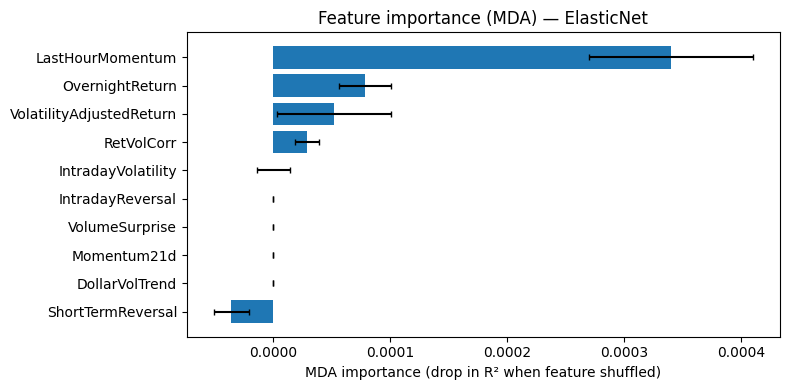

In [166]:
from sklearn.inspection import permutation_importance

# Use best model by validation R² for importance (or pick one, e.g. rf_best)
best_model_name = summary_df.loc[summary_df['Val_weighted_R2'].idxmax(), 'Model']
best_model = models_fitted[best_model_name]
print(f'Feature importance from best model: {best_model_name}\n')

# MDA: permutation importance on validation set (with sample weights)
perm = permutation_importance(
    best_model, X_val, y_val, n_repeats=8, random_state=42,
    sample_weight=w_val, scoring='r2', n_jobs=-1
)
imp_mda = pd.DataFrame({
    'Feature': feature_cols,
    'MDA_importance': perm.importances_mean,
    'MDA_std': perm.importances_std,
}).sort_values('MDA_importance', ascending=False)
print('MDA (permutation importance, validation set):')
display(imp_mda)

# MDI: tree-based importance (only for RF / XGBoost)
if hasattr(best_model, 'feature_importances_'):
    imp_mdi = pd.DataFrame({
        'Feature': feature_cols,
        'MDI_importance': best_model.feature_importances_,
    }).sort_values('MDI_importance', ascending=False)
    print('\nMDI (mean decrease impurity):')
    display(imp_mdi)
else:
    imp_mdi = imp_mda[['Feature']].copy()
    imp_mdi['MDI_importance'] = np.nan
    print('\nMDI not available (linear model).')

# Bar plot: MDA importance
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_mda['Feature'][::-1], imp_mda['MDA_importance'][::-1], xerr=imp_mda['MDA_std'][::-1], capsize=2)
ax.set_xlabel('MDA importance (drop in R² when feature shuffled)')
ax.set_title(f'Feature importance (MDA) — {best_model_name}')
plt.tight_layout()
plt.show()

### 7.2 Bin plots: most significant features vs target

For each of the top features (by MDA importance), we bin the feature into 4–5 bins and plot the mean target (and optionally mean prediction) in each bin to show the relationship with the target variable.

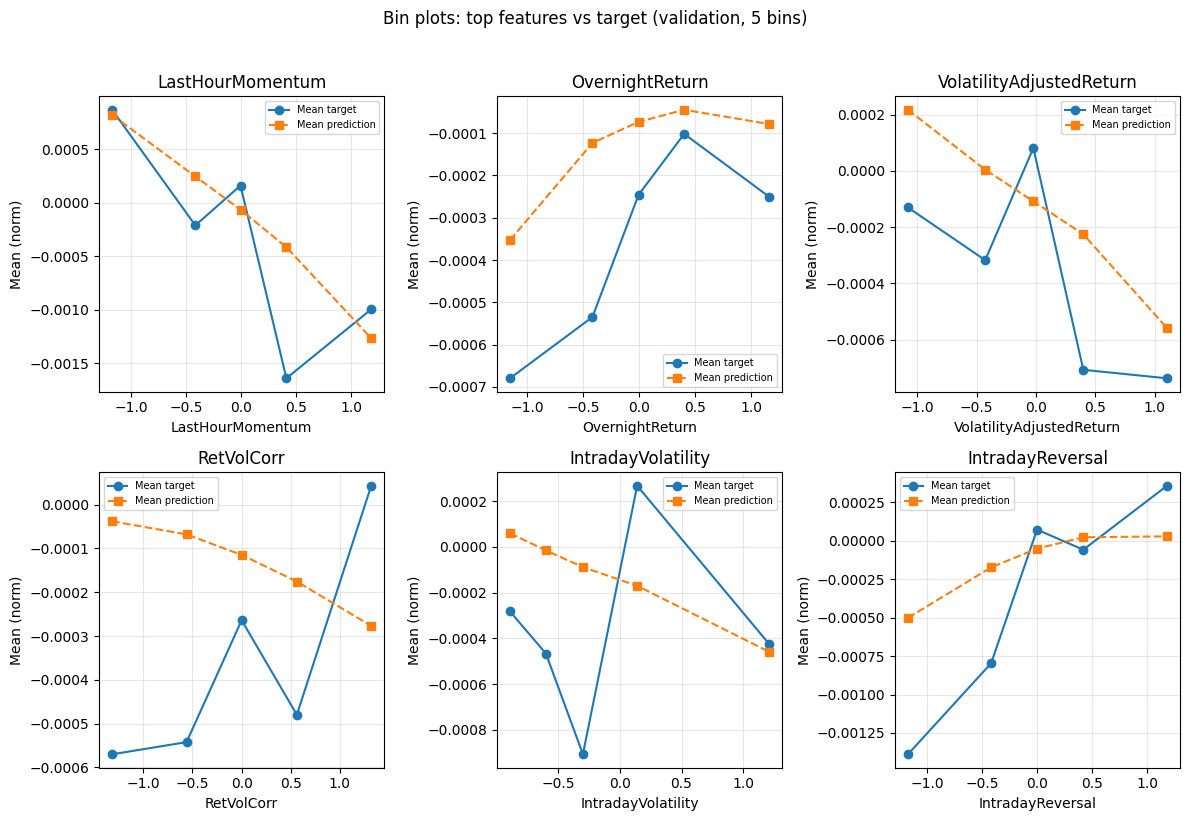

In [167]:
# Bin plots: top features vs target (validation set)
n_top = min(6, len(feature_cols))
top_features = imp_mda['Feature'].head(n_top).tolist()
n_bins = 5
val_plot = val_df[feature_cols + ['Target_norm']].copy()
val_plot['Pred_norm'] = best_model.predict(X_val)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for idx, feat in enumerate(top_features):
    ax = axes[idx]
    # Bin feature (quantile-based so each bin has similar count)
    val_plot['_bin'] = pd.qcut(val_plot[feat], q=n_bins, labels=False, duplicates='drop')
    binned = val_plot.groupby('_bin', observed=True).agg(
        mean_target=('Target_norm', 'mean'),
        mean_pred=('Pred_norm', 'mean'),
        mid_feat=(feat, 'median'),
    ).reset_index()
    x = binned['mid_feat'].values
    ax.plot(x, binned['mean_target'], 'o-', label='Mean target', color='C0')
    ax.plot(x, binned['mean_pred'], 's--', label='Mean prediction', color='C1')
    ax.set_xlabel(feat)
    ax.set_ylabel('Mean (norm)')
    ax.set_title(feat)
    ax.legend(loc='best', fontsize=7)
    ax.grid(True, alpha=0.3)
for j in range(len(top_features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Bin plots: top features vs target (validation, 5 bins)', y=1.02)
plt.tight_layout()
plt.show()

### Hold-out test: apply pre-trained model without refitting

Per spec: when the hold-out test year is provided, **do not refit**. Compute features and apply the saved model. Below: save best model and `feature_cols` so you can load and predict on new data.

### Performance on validation (2014) — for white paper

Per white paper requirements: final hyperparameters for each technique, R² weighted by 1/estVol, 30-day moving average of cross-sectional correlation (predictions vs target), and drift-style plot.

In [160]:
# Final hyperparameters for every technique (white paper table)
hp_ridge = {'alpha': best_alpha}
hp_rf = {'max_depth': int(best_rf['max_depth']), 'min_samples_leaf': int(best_rf['min_samples_leaf']), 'n_estimators': n_est_final}
hp_xgb = {'max_depth': int(best_xgb['max_depth']), 'learning_rate': best_xgb['learning_rate'], 'n_estimators': int(best_xgb['n_estimators'])} if HAS_XGB else {}
hp_en = {'alpha': best_en['alpha'], 'l1_ratio': best_en['l1_ratio']}
hyperparam_table = pd.DataFrame([
    ('Ridge', str(hp_ridge), ridge_val_r2),
    ('Random Forest', str(hp_rf), rf_val_r2),
    ('XGBoost', str(hp_xgb), xgb_val_r2 if HAS_XGB else np.nan),
    ('ElasticNet', str(hp_en), en_val_r2),
], columns=['Model', 'Final hyperparameters', 'Val weighted R² (√MDV_63)'])
print('Final hyperparameters and validation R² (for white paper):')
display(hyperparam_table)

Final hyperparameters and validation R² (for white paper):


,Model,Final hyperparameters,Val weighted R² (√MDV_63)
0,Ridge,{'alpha': 1000.0},0.000040
1,Random Forest,"{'max_depth': 5, 'min_samples_leaf': 10, 'n_es...",-0.000026
2,XGBoost,"{'max_depth': 3, 'learning_rate': 0.03, 'n_est...",0.000073
3,ElasticNet,"{'alpha': 0.0003727593720314938, 'l1_ratio': 0.5}",0.000179


#### White paper visualizations (export for appendix)

1. **Bin plot (validation 2014):** Predictions binned into 4; mean actual target per bin.  
2. **30-day MA correlation:** Cross-sectional correlation (pred vs target) and its 30-day moving average.  
3. **Drift plot:** Mean target by prediction bin over time (4 bins; ±1 SE bands).  
4. **Feature importance (MDA):** Bar chart of permutation importance (Section 7.1 below).

In [161]:
# R² weighted by 1/estVol (white paper: alternative weight)
w_estvol = 1.0 / val_df['EST_VOL_prev'].replace(0, np.nan)
w_estvol = w_estvol.fillna(w_estvol.median()).values  # avoid inf
r2_1estvol = r2_score(y_val, best_model.predict(X_val), sample_weight=w_estvol)
print(f'Validation R² weighted by 1/EST_VOL (white paper): {r2_1estvol:.6f}')
print(f'Validation R² weighted by √MDV_63 (benchmark):     {weighted_r2(y_val, best_model.predict(X_val), w_val):.6f}')

Validation R² weighted by 1/EST_VOL (white paper): 0.000201
Validation R² weighted by √MDV_63 (benchmark):     0.000179


In [ ]:
# Bin plot (white paper): 4 bins of predictions, mean actual target per bin — validation 2014
val_pred = val_df[['Date']].copy()
val_pred['Pred'] = best_model.predict(X_val)
val_pred['Target_norm'] = y_val
val_pred['Pred_bin'] = pd.qcut(val_pred['Pred'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
bin_stats = val_pred.groupby('Pred_bin', observed=True)['Target_norm'].agg(['mean', 'std', 'count'])
bin_stats['se'] = bin_stats['std'] / np.sqrt(bin_stats['count'])
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(bin_stats))
ax.bar(x, bin_stats['mean'], yerr=bin_stats['se'], capsize=5, color='steelblue', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(bin_stats.index)
ax.set_xlabel('Prediction bin (quartiles)')
ax.set_ylabel('Mean actual target (normalized)')
ax.set_title('Bin plot: predictions vs target (validation 2014)')
ax.axhline(y_val.mean(), color='gray', linestyle='--', alpha=0.7, label='Overall mean')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

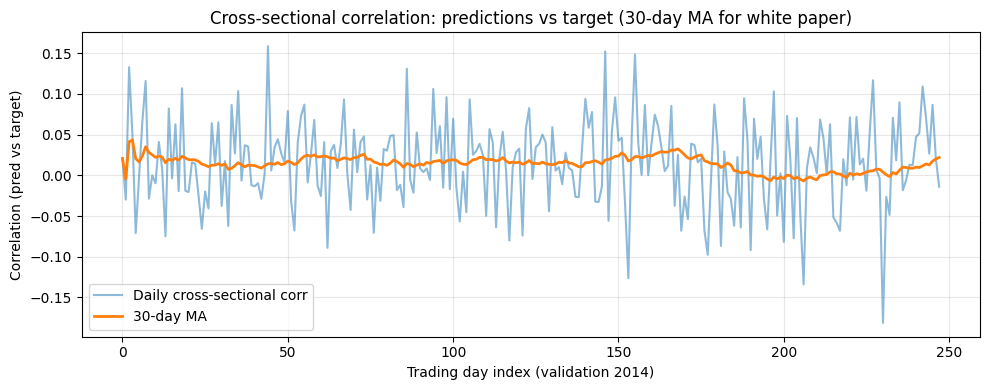

In [162]:
# 30-day moving average of cross-sectional correlation (predictions vs target) — white paper
val_pred = val_df[['Date']].copy()
val_pred['Pred'] = best_model.predict(X_val)
val_pred['Target_norm'] = y_val
daily_corr = val_pred.groupby('Date').apply(lambda g: g['Pred'].corr(g['Target_norm'])).reset_index()
daily_corr.columns = ['Date', 'corr']
daily_corr['corr_ma30'] = daily_corr['corr'].rolling(30, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(daily_corr)), daily_corr['corr'], alpha=0.5, label='Daily cross-sectional corr')
ax.plot(range(len(daily_corr)), daily_corr['corr_ma30'], label='30-day MA', color='C1', lw=2)
ax.set_xlabel('Trading day index (validation 2014)')
ax.set_ylabel('Correlation (pred vs target)')
ax.set_title('Cross-sectional correlation: predictions vs target (30-day MA for white paper)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

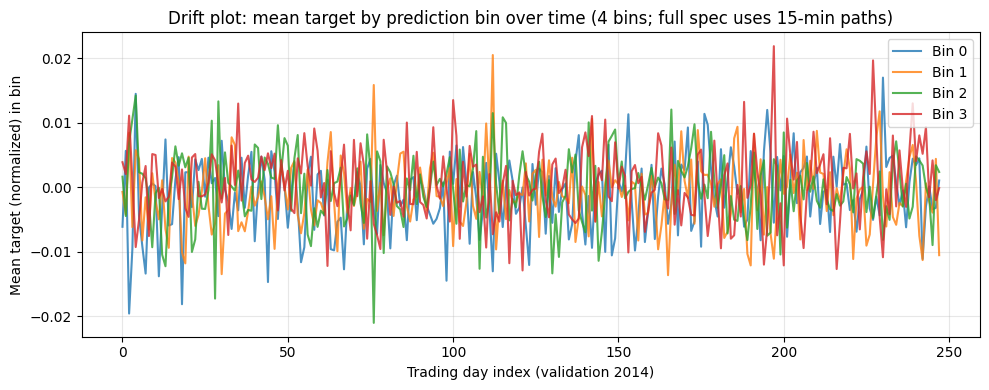

In [163]:
# Drift plot (white paper): 4 bins of predictions; mean target by bin over time with ±1 SE bands
# Full spec uses 15-min cumulative return paths from 24h before to 48h after; here we show mean target by bin per date.
val_drift = val_pred.copy()
val_drift['Bin'] = pd.qcut(val_drift['Pred'], q=4, labels=False, duplicates='drop')
drift_agg = val_drift.groupby(['Date', 'Bin'])['Target_norm'].agg(['mean', 'std', 'count']).reset_index()
drift_agg['se'] = drift_agg['std'] / np.sqrt(drift_agg['count'].clip(lower=1))
drift_by_date = drift_agg.pivot(index='Date', columns='Bin', values='mean')
se_by_date = drift_agg.pivot(index='Date', columns='Bin', values='se')
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(drift_by_date))
for b in drift_by_date.columns:
    mean_vals = drift_by_date[b].values
    se_vals = se_by_date[b].values if b in se_by_date.columns else np.zeros_like(mean_vals)
    se_vals = np.nan_to_num(se_vals, nan=0.0)
    ax.plot(x, mean_vals, label=f'Bin {b}', alpha=0.9)
    ax.fill_between(x, mean_vals - se_vals, mean_vals + se_vals, alpha=0.2)
ax.set_xlabel('Trading day index (validation 2014)')
ax.set_ylabel('Mean target (normalized) in bin')
ax.set_title('Drift plot: mean target by prediction bin over time (4 bins; ±1 SE bands)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [164]:
import pickle
from pathlib import Path

# Save best model and metadata for hold-out test (no refit when new data arrives)
model_dir = Path('saved_model')
model_dir.mkdir(exist_ok=True)
with open(model_dir / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open(model_dir / 'feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)
print(f'Saved {best_name} to {model_dir}/best_model.pkl and feature_cols to feature_cols.pkl')

# Example: load and predict on new data (no refit)
# with open(model_dir / 'best_model.pkl', 'rb') as f:
#     loaded_model = pickle.load(f)
# with open(model_dir / 'feature_cols.pkl', 'rb') as f:
#     loaded_feature_cols = pickle.load(f)
# X_new = new_df[loaded_feature_cols].astype(float)
# pred_norm = loaded_model.predict(X_new)
# pred_return = pred_norm * new_df['EST_VOL_prev'].values  # scale back to return space

Saved ElasticNet to saved_model/best_model.pkl and feature_cols to feature_cols.pkl
